# 📰 News Topic Classifier Using BERT (AG News)

This notebook fine-tunes `bert-base-uncased` on the **AG News** dataset to classify news headlines into 4 topic categories:

- 🌍 World
- ⚽ Sports
- 💼 Business
- 🔬 Sci/Tech

**Pipeline:**
1. Install dependencies
2. Load & explore the AG News dataset
3. Tokenize and preprocess
4. Fine-tune BERT using Hugging Face `Trainer`
5. Evaluate with Accuracy and F1-score
6. Save the model
7. Deploy a live demo with **Gradio** (works directly in Colab) — a **Streamlit** app file is also generated for local/cloud deployment




## 1. Install Dependencies

In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn gradio pyngrok
# Uninstall torchvision/torchaudio: not needed for this text task, and a version mismatch
# with torch in some Colab images causes an ImportError (VideoReader) inside datasets
# when it probes torchvision during training. Removing it avoids the issue entirely.
!pip uninstall -y torchvision torchaudio -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


## 3. Load the AG News Dataset

The AG News dataset has 4 classes: `World (0)`, `Sports (1)`, `Business (2)`, `Sci/Tech (3)`.
It contains 120,000 training samples and 7,600 test samples.


In [ ]:
raw_datasets = load_dataset("fancyzhx/ag_news")
print(raw_datasets)

label_names = raw_datasets["train"].features["label"].names
print("Labels:", label_names)

# Peek at a few examples
pd.DataFrame(raw_datasets["train"][:5])


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Labels: ['World', 'Sports', 'Business', 'Sci/Tech']


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


### (Optional) Use a smaller subset for faster experimentation

Training on the full 120k examples can take a while on a Colab GPU. Uncomment the lines below to
train on a smaller subset first to make sure everything works, then switch back to the full dataset
for your final run.


In [ ]:
# Set to True to use a smaller subset (recommended for a first test run)
USE_SUBSET = False
TRAIN_SUBSET_SIZE = 12000   # ~10% of training data
TEST_SUBSET_SIZE = 2000

if USE_SUBSET:
    train_dataset = raw_datasets["train"].shuffle(seed=42).select(range(TRAIN_SUBSET_SIZE))
    test_dataset = raw_datasets["test"].shuffle(seed=42).select(range(TEST_SUBSET_SIZE))
else:
    train_dataset = raw_datasets["train"]
    test_dataset = raw_datasets["test"]

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")


Train size: 120000, Test size: 7600


## 4. Tokenize and Preprocess

In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,  # dynamic padding handled by DataCollatorWithPadding
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Remove the raw text column, rename label -> labels (expected by Trainer)
tokenized_train = tokenized_train.remove_columns(["text"]).rename_column("label", "labels")
tokenized_test = tokenized_test.remove_columns(["text"]).rename_column("label", "labels")

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_train


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 120000
})

## 5. Load the Pretrained BERT Model for Classification

In [ ]:
num_labels = len(label_names)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
)
model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 6. Define Evaluation Metrics (Accuracy & F1-score)

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}


## 7. Set Up Training Arguments & Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert-ag-news",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",  # disable wandb/other loggers
    fp16=torch.cuda.is_available(),  # mixed precision if GPU available
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


## 8. Fine-Tune the Model

This will train for 3 epochs and evaluate at the end of each epoch. Training time depends on
dataset size and whether you're using a GPU (Colab GPU: a few minutes on the subset, longer on
the full dataset).


In [15]:
train_result = trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.189518,0.178676,0.942500,0.942526
2,0.112316,0.189731,0.948026,0.948042


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.189518,0.178676,0.942500,0.942526
2,0.112316,0.189731,0.948026,0.948042
3,0.078393,0.224114,0.947632,0.947640


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

## 9. Evaluate the Fine-Tuned Model

In [16]:
eval_metrics = trainer.evaluate()
print(eval_metrics)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.078393,0.189866,3,0.948289,0.948305


{'eval_loss': 0.18986594676971436, 'eval_accuracy': 0.9482894736842106, 'eval_f1': 0.9483045758353398}


              precision    recall  f1-score   support

       World       0.96      0.96      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.92      0.92      1900
    Sci/Tech       0.92      0.93      0.92      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



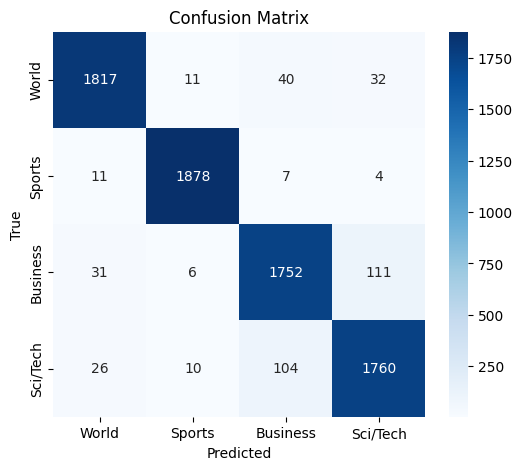

In [17]:
# Detailed classification report
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print(classification_report(labels, preds, target_names=label_names))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## 10. Save the Fine-Tuned Model

We'll save the model and tokenizer so they can be reloaded later (e.g., in the Gradio/Streamlit app).


In [20]:
SAVE_DIR = "./bert-ag-news-finetuned"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model saved to {SAVE_DIR}")

# Zip the model folder
!zip -r bert-ag-news-finetuned.zip {SAVE_DIR}

from google.colab import files
files.download("bert-ag-news-finetuned.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert-ag-news-finetuned
  adding: bert-ag-news-finetuned/ (stored 0%)
  adding: bert-ag-news-finetuned/config.json (deflated 54%)
  adding: bert-ag-news-finetuned/tokenizer.json (deflated 71%)
  adding: bert-ag-news-finetuned/tokenizer_config.json (deflated 43%)
  adding: bert-ag-news-finetuned/training_args.bin (deflated 54%)
  adding: bert-ag-news-finetuned/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Quick Inference Test

In [21]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=0 if torch.cuda.is_available() else -1,
)

sample_headlines = [
    "Apple unveils new AI-powered chip for next-gen iPhones",
    "Manchester United wins thrilling match in the final minute",
    "Stock markets rally after positive inflation report",
    "NASA announces new mission to explore Jupiter's moons",
]

for headline in sample_headlines:
    result = classifier(headline)[0]
    print(f"'{headline}'\n  -> {result['label']} (score: {result['score']:.4f})\n")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

'Apple unveils new AI-powered chip for next-gen iPhones'
  -> Sci/Tech (score: 0.9894)

'Manchester United wins thrilling match in the final minute'
  -> Sports (score: 0.8177)

'Stock markets rally after positive inflation report'
  -> Business (score: 0.9930)

'NASA announces new mission to explore Jupiter's moons'
  -> Sci/Tech (score: 0.9042)



## 12. Live Demo with Gradio (runs directly in Colab)

This launches an interactive web UI right inside Colab (and gives you a shareable public link via `share=True`).


In [22]:
import gradio as gr

def predict_topic(headline):
    if not headline.strip():
        return "Please enter a headline."
    result = classifier(headline)[0]
    return f"Predicted Category: {result['label']}  (confidence: {result['score']:.2%})"

demo = gr.Interface(
    fn=predict_topic,
    inputs=gr.Textbox(lines=2, placeholder="Enter a news headline...", label="News Headline"),
    outputs=gr.Textbox(label="Prediction"),
    title="📰 News Topic Classifier (BERT fine-tuned on AG News)",
    description="Enter a news headline and the fine-tuned BERT model will classify it into World, Sports, Business, or Sci/Tech.",
    examples=[
        ["Federal Reserve raises interest rates amid inflation concerns"],
        ["Olympic champion breaks world record in 100m sprint"],
        ["New exoplanet discovered that may support liquid water"],
        ["United Nations calls for ceasefire amid rising tensions"],
    ],
)

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55c60a47ce222afa38.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 13. (Optional) Standalone Streamlit App

Gradio above runs fine inside Colab. If you'd rather deploy with **Streamlit** (e.g., on Streamlit
Community Cloud, or run locally), the cell below writes out a standalone `app.py` file you can take
with you. It expects the `bert-ag-news-finetuned` model folder (saved in step 10) to sit alongside it.


In [23]:
%%writefile app.py
import streamlit as st
from transformers import pipeline

st.set_page_config(page_title="News Topic Classifier", page_icon="📰")

st.title("📰 News Topic Classifier")
st.write("Fine-tuned BERT model trained on the AG News dataset. Classifies headlines into "
         "**World**, **Sports**, **Business**, or **Sci/Tech**.")

MODEL_DIR = "bert-ag-news-finetuned"

@st.cache_resource
def load_classifier():
    return pipeline("text-classification", model=MODEL_DIR, tokenizer=MODEL_DIR)

classifier = load_classifier()

headline = st.text_area("Enter a news headline:", height=100,
                         placeholder="e.g., Central bank cuts interest rates to boost economy")

if st.button("Classify"):
    if headline.strip():
        result = classifier(headline)[0]
        st.success(f"**Predicted Category:** {result['label']}")
        st.write(f"Confidence: {result['score']:.2%}")
    else:
        st.warning("Please enter a headline first.")

st.markdown("---")
st.caption("Model: bert-base-uncased, fine-tuned on AG News · Built with Hugging Face Transformers + Streamlit")


Writing app.py


In [24]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 64.8 MB/s eta 0:00:00


In [25]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 3s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋npm notice
npm notice New major version of npm available! 10.8.2 -> 11.18.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.18.0
npm notice To update run: npm install -g npm@11.18.0
npm notice
⠋

In [26]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://cold-waves-tell.loca.lt
